Visual Storyteller: data, model and training

In [2]:
import os
import torchvision
import torch
from PIL import Image
import pandas as pd
from collections import Counter
torch.manual_seed(42)
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.nn.utils.rnn import pad_sequence
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
#make sure captions loaded correctly
df=pd.read_csv('captions.txt')
print(df.head())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


In [4]:
print("total rows:", len(df))

total rows: 40455


In [5]:
#map words to numbers
def get_vocab(df, min_count=2):
    word_counts = Counter()
    for text in df['caption']:
        word_counts.update(text.lower().split())
    
    #special tokens
    mapping = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
    for word, count in word_counts.items():
        if count >= min_count:
            mapping[word] = len(mapping)
    return mapping

word_to_idx = get_vocab(df)
print("total unique words:", len(word_to_idx))

total unique words: 5241


In [6]:
print("unique images:", df['image'].nunique())

unique images: 8091


dataset and dataloader

In [7]:
class FlickrDataset(Dataset):
    def __init__(self, data, img_dir, word_map):
        self.data = data
        self.img_dir = img_dir
        self.word_map = word_map
        
        # resize and normalize using imagenet stats
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'])
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)

        words = row['caption'].lower().split()
        caption_ids = [self.word_map['<START>']]
        caption_ids += [self.word_map.get(w, self.word_map['<UNK>']) for w in words]
        caption_ids += [self.word_map['<END>']]


        return img, torch.tensor(caption_ids)

In [8]:
IMG_DIR="Images"

dataset=FlickrDataset(df, IMG_DIR, word_to_idx)
img, caption_ids=dataset[0]
print(f"image shape:{img.shape}")
print(f"caption length:{len(caption_ids)}")
print(f"first few token id:{caption_ids[:6]}")

image shape:torch.Size([3, 224, 224])
caption length:20
first few token id:tensor([1, 4, 5, 6, 4, 7])


In [9]:
def collate_fn(batch):
    imgs, captions=zip(*batch)
    imgs=torch.stack(imgs)
    captions=pad_sequence(captions, batch_first=True, padding_value=word_to_idx['<PAD>'])
    return imgs, captions

# train/val split
train_size=int(0.9 * len(dataset))
val_size=len(dataset)-train_size
train_data, val_data=torch.utils.data.random_split(dataset, [train_size, val_size])


train_loader=DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader=DataLoader(val_data, batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)

In [10]:
print(f"train batches:{len(train_loader)}")
print(f"val batches:{len(val_loader)}")

train batches:1138
val batches:127


 Encoder and decoder

In [11]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        resnet = models.resnet18(weights='DEFAULT')
        #remove final classification layer
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        #freeze encoder weights
        for param in self.resnet.parameters():
            param.requires_grad = False
        self.fc = nn.Linear(512, embed_dim)

    def forward(self, imgs):
        with torch.no_grad():
            features = self.resnet(imgs)
        features = features.squeeze(-1).squeeze(-1)
        return self.fc(features)

In [12]:
class DecoderLSTM(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.init_hidden = nn.Linear(embed_dim, hidden_dim)


    def forward(self, features, captions):
        #image features as initial hidden state
        hidden = self.init_hidden(features).unsqueeze(0)
        cell = torch.zeros_like(hidden)
        embeddings = self.embedding(captions[:, :-1])
        outputs, _ = self.lstm(embeddings, (hidden, cell))
        return self.fc(outputs)

training

In [13]:
#training
embed_dim = 256
hidden_dim = 512
num_epochs = 10
learning_rate = 3e-4
encoder = EncoderCNN(embed_dim=embed_dim).cuda()
encoder.eval()
decoder = DecoderLSTM(embed_dim=embed_dim, hidden_dim=hidden_dim, vocab_size=len(word_to_idx)).cuda()
criterion = nn.CrossEntropyLoss(ignore_index=word_to_idx['<PAD>'])
params = list(decoder.parameters()) + list(encoder.fc.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate)

In [14]:
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    decoder.train()
    total_loss = 0

    for imgs, captions in train_loader:
        imgs = imgs.cuda()
        captions = captions.cuda()
        optimizer.zero_grad()
        features = encoder(imgs)
        outputs = decoder(features, captions)
        #reshape for loss
        outputs = outputs.reshape(-1, len(word_to_idx))
        targets = captions[:, 1:].reshape(-1)
        loss = criterion(outputs, targets)
        loss.backward()
        #clip gradients 
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1)
        optimizer.step()
        total_loss += loss.item()

    train_avg = total_loss / len(train_loader)
    train_losses.append(train_avg)

    #validation
    decoder.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, captions in val_loader:
            imgs = imgs.cuda()
            captions = captions.cuda()
            features = encoder(imgs)
            outputs = decoder(features, captions)
            outputs = outputs.reshape(-1, len(word_to_idx))
            targets = captions[:, 1:].reshape(-1)
            val_loss += criterion(outputs, targets).item()

    val_avg = val_loss / len(val_loader)
    val_losses.append(val_avg)
    print(f"epoch {epoch+1}/{num_epochs}, train:{train_avg:.4f}, val:{val_avg:.4f}")

epoch 1/10, train:3.8130, val:3.3502
epoch 2/10, train:3.1568, val:3.0841
epoch 3/10, train:2.8672, val:2.8981
epoch 4/10, train:2.6655, val:2.7906
epoch 5/10, train:2.5139, val:2.7255
epoch 6/10, train:2.3891, val:2.6865
epoch 7/10, train:2.2798, val:2.6644
epoch 8/10, train:2.1796, val:2.6472
epoch 9/10, train:2.0865, val:2.6432
epoch 10/10, train:1.9983, val:2.6426


In [14]:
#save model and vocab
torch.save({
    'encoder': encoder.state_dict(),
    'decoder': decoder.state_dict(),
    'vocab': word_to_idx,
    'embed_dim': embed_dim,
    'hidden_dim': hidden_dim
}, 'model.pth')
print("saved")

saved


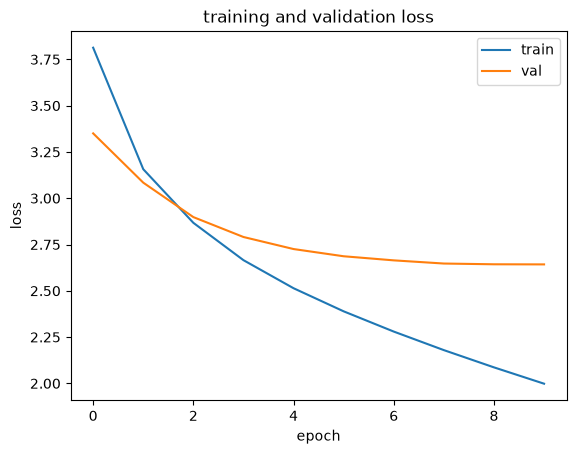

In [16]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("training and validation loss")
plt.savefig("loss.png")
plt.show()

In [15]:
#trying higher learning rate to compare
embed_dim2 = 256
hidden_dim2 = 512
num_epochs2 = 5
learning_rate2 = 1e-3
encoder2 = EncoderCNN(embed_dim=embed_dim2).cuda()
encoder2.eval()
decoder2 = DecoderLSTM(embed_dim=embed_dim2, hidden_dim=hidden_dim2, vocab_size=len(word_to_idx)).cuda()
criterion2 = nn.CrossEntropyLoss(ignore_index=word_to_idx['<PAD>'])
params2 = list(decoder2.parameters()) + list(encoder2.fc.parameters())
optimizer2 = torch.optim.Adam(params2, lr=learning_rate2)

exp_train_losses = []
for epoch in range(num_epochs2):
    decoder2.train()
    total_loss = 0
    for imgs, captions in train_loader:
        imgs = imgs.cuda()
        captions = captions.cuda()
        optimizer2.zero_grad()
        features = encoder2(imgs)
        outputs = decoder2(features, captions)
        outputs = outputs.reshape(-1, len(word_to_idx))
        targets = captions[:, 1:].reshape(-1)
        loss = criterion2(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder2.parameters(), max_norm=1)
        optimizer2.step()
        total_loss += loss.item()

    avg = total_loss / len(train_loader)
    exp_train_losses.append(avg)
    print(f"epoch {epoch+1}/{num_epochs2}, loss:{avg:.4f}")

epoch 1/5, loss:3.4528
epoch 2/5, loss:2.8626
epoch 3/5, loss:2.6149
epoch 4/5, loss:2.4129
epoch 5/5, loss:2.2290


In [16]:
checkpoint = torch.load('model.pth', map_location='cpu')
print(checkpoint['embed_dim'], checkpoint['hidden_dim'])

256 512


C:\Users\Giorgi\AppData\Local\Temp\ipykernel_6128\1596955068.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('model.pth', map_location='cpu')
